In [1]:
%matplotlib inline

In [2]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
#Import your modules here
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
PARSED_DATA_DIR = PROJECT_ROOT / "data" / "parsed_sales_runs"

#Manually select the appropriate folder with the latest imot.bg scrape data
LATEST_RUN = "parsed_sales_full_20260608_081646"

In [4]:
ml_model_base_df = pd.read_parquet(PARSED_DATA_DIR / LATEST_RUN / "imot_ml_ready.parquet")
ml_model_base_df

,ad_id,ad_url,listing_type,property_type_raw,currency,vat_status,title_city_model,title_geo_2_model,geo_category,total_price,area_sqm,price_per_sqm,views,features_count,construction_type_model,construction_year_model,floor_model,total_floors_model,floor_applicability,features_pipe
0,1a155107752004273,https://www.imot.bg/obiava-1a155107752004273-p...,single_property_listing,1-СТАЕН,EUR,with_vat,област пазарджик,велинград,mountain_resort,57100.0,44.0,1297.73,9.0,5,Тухла,2026.0,1.0,4.0,applicable,Тухла|Асансьор|С гараж|С паркинг|Лизинг
1,1a146979303032401,https://www.imot.bg/obiava-1a146979303032401-p...,single_property_listing,1-СТАЕН,EUR,with_vat,град софия,малинова долина,capital_non_center,103000.0,36.0,2861.11,734.0,1,Тухла,2027.0,2.0,4.0,applicable,Тухла
2,1a140680337846667,https://www.imot.bg/obiava-1a140680337846667-p...,single_property_listing,1-СТАЕН,EUR,unknown,град варна,ален мак,large_regional_city,15000.0,30.0,500.00,13987.0,3,Тухла,2014.0,0.0,3.0,applicable,Тухла|Лизинг|Бартер
3,1a154997703660554,https://www.imot.bg/obiava-1a154997703660554-p...,single_property_listing,1-СТАЕН,EUR,no_vat,област бургас,свети влас,sea_resort,73600.0,48.0,1533.33,24930.0,11,Тухла,2015.0,1.0,5.0,applicable,Тухла|Асансьор|С паркинг|Лизинг|Интернет връзк...
4,1a155107630313014,https://www.imot.bg/obiava-1a155107630313014-p...,single_property_listing,1-СТАЕН,EUR,with_vat,област пазарджик,велинград,mountain_resort,52200.0,48.0,1087.50,4.0,7,Тухла,2027.0,0.0,2.0,applicable,Тухла|Асансьор|С гараж|С паркинг|Лизинг|Интерн...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160516,1t178040581246461,https://www.imot.bg/obiava-1t178040581246461-p...,single_property_listing,СТОМАТОЛОГИЧЕН КАБИНЕТ,EUR,with_vat,град софия,лозенец,capital_center,150000.0,33.0,4545.45,89.0,1,Тухла,1960.0,0.0,6.0,applicable,Тухла
160517,1t178068775213524,https://www.imot.bg/obiava-1t178068775213524-p...,single_property_listing,ФАБРИКА/ЗАВОД,EUR,unknown,област благоевград,разлог,mountain_resort,219000.0,3500.0,62.57,30.0,4,Панел,2012.0,NaN,NaN,applicable,Панел|Асансьор|С паркинг|С действащ бизнес
160518,1t178057118615306,https://www.imot.bg/obiava-1t178057118615306-p...,single_property_listing,САМОСТОЯТЕЛНА СГРАДА,EUR,without_vat,град софия,люлин 10,capital_non_center,2300000.0,1100.0,2090.91,131.0,1,Тухла,2026.0,NaN,NaN,applicable,Тухла
160519,1t178056904401452,https://www.imot.bg/obiava-1t178056904401452-p...,single_property_listing,ТЪРГОВСКИ КОМПЛЕКС,EUR,no_vat,град софия,дружба 2,capital_non_center,3100000.0,2500.0,1240.00,86.0,11,Тухла,2007.0,NaN,NaN,applicable,Тухла|Асансьор|С гараж|С паркинг|Интернет връз...


In [5]:
residential_property_types = [
    "1-СТАЕН",
    "2-СТАЕН",
    "3-СТАЕН",
    "4-СТАЕН",
    "МНОГОСТАЕН",
    "МЕЗОНЕТ",
    "КЪЩА",
    "ЕТАЖ ОТ КЪЩА",
    "ВИЛА",
    "АТЕЛИЕ, ТАВАН",
]

residential_df = ml_model_base_df[
    ml_model_base_df["property_type_raw"].isin(residential_property_types)
].copy()

residential_df.shape

(110136, 20)

In [6]:
ppm = residential_df["price_per_sqm"].dropna()

ppm_desc = ppm.describe()
ppm_desc

count    110136.000000
mean       1737.287144
std        1280.172203
min           0.280000
25%        1152.780000
50%        1569.655000
75%        2200.000000
max      210000.000000
Name: price_per_sqm, dtype: float64

In [7]:
mean_ppm = ppm.mean()
median_ppm = ppm.median()
std_ppm = ppm.std()

mean_ppm, median_ppm, std_ppm

(np.float64(1737.2871443488052),
 np.float64(1569.6550000000002),
 np.float64(1280.1722028681534))

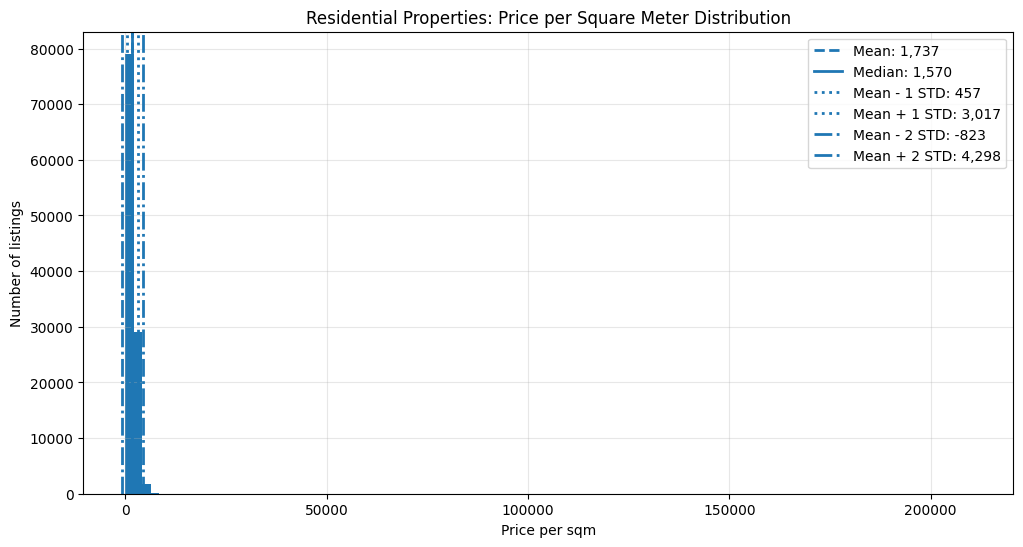

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(ppm, bins=100)

# Mean and median
plt.axvline(mean_ppm, linestyle="--", linewidth=2, label=f"Mean: {mean_ppm:,.0f}")
plt.axvline(median_ppm, linestyle="-", linewidth=2, label=f"Median: {median_ppm:,.0f}")

# ±1 standard deviation
plt.axvline(mean_ppm - std_ppm, linestyle=":", linewidth=2, label=f"Mean - 1 STD: {mean_ppm - std_ppm:,.0f}")
plt.axvline(mean_ppm + std_ppm, linestyle=":", linewidth=2, label=f"Mean + 1 STD: {mean_ppm + std_ppm:,.0f}")

# ±2 standard deviations
plt.axvline(mean_ppm - 2 * std_ppm, linestyle="-.", linewidth=2, label=f"Mean - 2 STD: {mean_ppm - 2 * std_ppm:,.0f}")
plt.axvline(mean_ppm + 2 * std_ppm, linestyle="-.", linewidth=2, label=f"Mean + 2 STD: {mean_ppm + 2 * std_ppm:,.0f}")

plt.title("Residential Properties: Price per Square Meter Distribution")
plt.xlabel("Price per sqm")
plt.ylabel("Number of listings")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
features_series = (
    residential_df["features_pipe"]
    .dropna()
    .astype(str)
    .str.split("|")
    .explode()
    .str.strip()
)

features_series = features_series[features_series != ""]

residential_features_counts = (
    features_series
    .value_counts()
    .rename_axis("feature")
    .reset_index(name="count")
)

residential_features_counts["share_of_residential_listings"] = (
    residential_features_counts["count"] / len(residential_df)
)

residential_features_counts

,feature,count,share_of_residential_listings
0,Тухла,97844,0.888393
1,Асансьор,53926,0.489631
2,Контрол на достъпа,35736,0.324472
3,Обзаведен,28998,0.263293
4,С паркинг,27969,0.253950
...,...,...,...
392,Отделна маза,1,0.000009
393,Имотът предлага добра основа за обновление и п...,1,0.000009
394,Код на Имота: 3228,1,0.000009
395,Самостоятелен двор,1,0.000009


In [10]:
print("Residential rows:", len(residential_df))
print("Rows with non-empty features_pipe:", residential_df["features_pipe"].notna().sum())
print("Unique residential features:", residential_features_counts.shape[0])

residential_features_counts.head(75)

Residential rows: 110136
Rows with non-empty features_pipe: 110136
Unique residential features: 397


,feature,count,share_of_residential_listings
0,Тухла,97844,0.888393
1,Асансьор,53926,0.489631
2,Контрол на достъпа,35736,0.324472
3,Обзаведен,28998,0.263293
4,С паркинг,27969,0.253950
...,...,...,...
70,Изложение: Ю,1,0.000009
71,Прекрасен двор,1,0.000009
72,-4-ти (последен) жилищен етаж,1,0.000009
73,-Без асансьор,1,0.000009


In [11]:
feature_cutoff_diagnostics = residential_features_counts.copy()

feature_cutoff_diagnostics["cumulative_count"] = feature_cutoff_diagnostics["count"].cumsum()
feature_cutoff_diagnostics["cumulative_share_of_feature_mentions"] = (
    feature_cutoff_diagnostics["cumulative_count"] /
    feature_cutoff_diagnostics["count"].sum()
)

feature_cutoff_diagnostics.head(100)

,feature,count,share_of_residential_listings,cumulative_count,cumulative_share_of_feature_mentions
0,Тухла,97844,0.888393,97844,0.264828
1,Асансьор,53926,0.489631,151770,0.410785
2,Контрол на достъпа,35736,0.324472,187506,0.507510
3,Обзаведен,28998,0.263293,216504,0.585996
4,С паркинг,27969,0.253950,244473,0.661698
...,...,...,...,...,...
95,-В непосредствена близост се намират детската ...,1,0.000009,369162,0.999185
96,"-Двустайни апартаменти от 64,74м2 до 71,11м2.",1,0.000009,369163,0.999188
97,"-Тристайни апартаменти от 86,92м2 до 178,56м2.",1,0.000009,369164,0.999191
98,"-Четиристайни апартаменти от 102,75м2 до 162,93м2",1,0.000009,369165,0.999193


In [12]:
for cutoff in [10, 25, 50, 100, 250, 500, 1000]:
    n_features = (residential_features_counts["count"] >= cutoff).sum()
    print(f"cutoff >= {cutoff:>4}: {n_features:>3} features")

cutoff >=   10:  25 features
cutoff >=   25:  25 features
cutoff >=   50:  24 features
cutoff >=  100:  23 features
cutoff >=  250:  22 features
cutoff >=  500:  20 features
cutoff >= 1000:  20 features


In [13]:
min_count = 100

selected_residential_features = (
    residential_features_counts
    .loc[residential_features_counts["count"] >= min_count, "feature"]
    .tolist()
)

selected_residential_features

['Тухла',
 'Асансьор',
 'Контрол на достъпа',
 'Обзаведен',
 'С паркинг',
 'Саниран',
 'С гараж',
 'Видео наблюдение',
 'Интернет връзка',
 'В затворен комплекс',
 'Охрана',
 'Панел',
 'За ремонт',
 'Възможност за дан. кредит',
 'Гредоред',
 'Лизинг',
 'С преход',
 'ЕПК',
 'С действащ бизнес',
 'В строеж',
 'Сглобяема конструкция',
 'Бартер',
 'Ипотекиран']

In [14]:
selected_residential_features_set = set(selected_residential_features)

for feature in selected_residential_features:
    col_name = "feature_" + (
        feature
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(",", "")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    residential_df[col_name] = (
        residential_df["features_pipe"]
        .fillna("")
        .astype(str)
        .str.split("|")
        .apply(lambda features: int(feature in [f.strip() for f in features]))
    )

In [15]:
feature_dummy_cols = [
    col for col in residential_df.columns
    if col.startswith("feature_")
]

len(feature_dummy_cols), feature_dummy_cols

(23,
 ['feature_тухла',
  'feature_асансьор',
  'feature_контрол_на_достъпа',
  'feature_обзаведен',
  'feature_с_паркинг',
  'feature_саниран',
  'feature_с_гараж',
  'feature_видео_наблюдение',
  'feature_интернет_връзка',
  'feature_в_затворен_комплекс',
  'feature_охрана',
  'feature_панел',
  'feature_за_ремонт',
  'feature_възможност_за_дан._кредит',
  'feature_гредоред',
  'feature_лизинг',
  'feature_с_преход',
  'feature_епк',
  'feature_с_действащ_бизнес',
  'feature_в_строеж',
  'feature_сглобяема_конструкция',
  'feature_бартер',
  'feature_ипотекиран'])

In [16]:
encoded_feature_check = []

for feature in selected_residential_features:
    col_name = "feature_" + (
        feature
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(",", "")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    encoded_feature_check.append({
        "feature": feature,
        "encoded_col": col_name,
        "encoded_count": residential_df[col_name].sum()
    })

encoded_feature_check_df = pd.DataFrame(encoded_feature_check)

encoded_feature_check_df = encoded_feature_check_df.merge(
    residential_features_counts[["feature", "count"]],
    on="feature",
    how="left"
)

encoded_feature_check_df["matches_original_count"] = (
    encoded_feature_check_df["encoded_count"] == encoded_feature_check_df["count"]
)

encoded_feature_check_df

,feature,encoded_col,encoded_count,count,matches_original_count
0,Тухла,feature_тухла,97844,97844,True
1,Асансьор,feature_асансьор,53926,53926,True
2,Контрол на достъпа,feature_контрол_на_достъпа,35736,35736,True
3,Обзаведен,feature_обзаведен,28998,28998,True
4,С паркинг,feature_с_паркинг,27969,27969,True
5,Саниран,feature_саниран,24513,24513,True
6,С гараж,feature_с_гараж,17076,17076,True
7,Видео наблюдение,feature_видео_наблюдение,16516,16516,True
8,Интернет връзка,feature_интернет_връзка,16464,16464,True
9,В затворен комплекс,feature_в_затворен_комплекс,11931,11931,True


In [17]:
residential_df[
    ["property_type_raw", "price_per_sqm", "features_pipe"] + feature_dummy_cols
].head()

,property_type_raw,price_per_sqm,features_pipe,feature_тухла,feature_асансьор,feature_контрол_на_достъпа,feature_обзаведен,feature_с_паркинг,feature_саниран,feature_с_гараж,...,feature_възможност_за_дан._кредит,feature_гредоред,feature_лизинг,feature_с_преход,feature_епк,feature_с_действащ_бизнес,feature_в_строеж,feature_сглобяема_конструкция,feature_бартер,feature_ипотекиран
0,1-СТАЕН,1297.73,Тухла|Асансьор|С гараж|С паркинг|Лизинг,1,1,0,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
1,1-СТАЕН,2861.11,Тухла,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1-СТАЕН,500.00,Тухла|Лизинг|Бартер,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,1-СТАЕН,1533.33,Тухла|Асансьор|С паркинг|Лизинг|Интернет връзк...,1,1,1,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
4,1-СТАЕН,1087.50,Тухла|Асансьор|С гараж|С паркинг|Лизинг|Интерн...,1,1,1,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0


In [18]:
residential_df["strata"] = (
    residential_df["geo_category"].astype(str)
    + "__"
    + residential_df["property_type_raw"].astype(str)
)

In [19]:
strata_counts = (
    residential_df
    .assign(
        strata=lambda df: (
            df["geo_category"].astype(str)
            + "__"
            + df["property_type_raw"].astype(str)
        )
    )
    ["strata"]
    .value_counts()
    .reset_index()
)

strata_counts.columns = ["strata", "count"]

strata_counts.describe()

,count
count,80.000000
mean,1376.700000
std,2774.642604
min,1.000000
25%,66.500000
50%,337.000000
75%,1107.250000
max,13428.000000


In [20]:
strata_counts[strata_counts["count"] < 10].sort_values("count")

,strata,count
78,capital_center__ВИЛА,1
77,"small_city__АТЕЛИЕ, ТАВАН",2
76,"mountain_resort__АТЕЛИЕ, ТАВАН",4


In [20]:
split_df = residential_df.copy()

split_df["strata_raw"] = (
    split_df["geo_category"].astype(str)
    + "__"
    + split_df["property_type_raw"].astype(str)
)

min_stratum_size = 20

strata_counts = split_df["strata_raw"].value_counts()
valid_strata = strata_counts[strata_counts >= min_stratum_size].index

split_df["strata"] = split_df["strata_raw"].where(
    split_df["strata_raw"].isin(valid_strata),
    "OTHER_SMALL_STRATA"
)

split_df["strata"].value_counts().sort_values().head(20)

strata
capital_center__АТЕЛИЕ, ТАВАН         22
mountain_resort__ВИЛА                 22
large_regional_city__АТЕЛИЕ, ТАВАН    25
capital_non_center__ВИЛА              25
village__4-СТАЕН                      25
mountain_resort__МНОГОСТАЕН           26
small_city__МЕЗОНЕТ                   31
mountain_resort__МЕЗОНЕТ              33
capital_center__ЕТАЖ ОТ КЪЩА          41
large_regional_city__ВИЛА             46
mountain_resort__ЕТАЖ ОТ КЪЩА         49
OTHER_SMALL_STRATA                    49
mountain_resort__4-СТАЕН              53
capital_non_center__АТЕЛИЕ, ТАВАН     56
regional_city__АТЕЛИЕ, ТАВАН          70
sea_resort__ЕТАЖ ОТ КЪЩА              82
village__1-СТАЕН                      88
sea_resort__ВИЛА                      91
capital_center__МЕЗОНЕТ               92
village__ЕТАЖ ОТ КЪЩА                 93
Name: count, dtype: int64

In [22]:
split_df["strata"].value_counts().sort_values().head(20)

strata
large_regional_city__АТЕЛИЕ, ТАВАН    21
sea_resort__АТЕЛИЕ, ТАВАН             21
mountain_resort__ВИЛА                 22
village__4-СТАЕН                      25
small_city__МЕЗОНЕТ                   27
mountain_resort__МНОГОСТАЕН           28
capital_center__ЕТАЖ ОТ КЪЩА          32
mountain_resort__МЕЗОНЕТ              33
large_regional_city__ВИЛА             46
mountain_resort__ЕТАЖ ОТ КЪЩА         49
capital_non_center__АТЕЛИЕ, ТАВАН     53
mountain_resort__4-СТАЕН              53
OTHER_SMALL_STRATA                    66
regional_city__АТЕЛИЕ, ТАВАН          68
sea_resort__ЕТАЖ ОТ КЪЩА              84
sea_resort__ВИЛА                      84
village__1-СТАЕН                      85
capital_center__КЪЩА                  92
village__ЕТАЖ ОТ КЪЩА                 97
capital_center__МЕЗОНЕТ               99
Name: count, dtype: int64

In [21]:
target_col = "price_per_sqm"

train_val_df, test_df = train_test_split(
    split_df,
    test_size=0.20,
    random_state=42,
    stratify=split_df["strata"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42,
    stratify=train_val_df["strata"]
)

In [22]:
drop_cols = [
    "price_per_sqm",
    "total_price",
    "ad_id",
    "ad_url",
    "features_pipe",
    "strata_raw",
    "strata",
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

In [23]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66081 entries, 94372 to 30865
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   listing_type                       66081 non-null  string 
 1   property_type_raw                  66081 non-null  string 
 2   currency                           66081 non-null  string 
 3   vat_status                         66081 non-null  string 
 4   title_city_model                   66081 non-null  string 
 5   title_geo_2_model                  66081 non-null  string 
 6   geo_category                       66081 non-null  string 
 7   area_sqm                           66081 non-null  float64
 8   views                              66081 non-null  float64
 9   features_count                     66081 non-null  int64  
 10  construction_type_model            66081 non-null  string 
 11  construction_year_model            66081 non-null  floa

In [24]:
drop_feature_cols = [
    "listing_type",
    "currency",
    "vat_status",
    "floor_applicability",
]

binary_feature_cols = [
    col for col in X_train.columns
    if col.startswith("feature_")
]

numeric_cols = [
    "area_sqm",
    "views",
    "features_count",
    "construction_year_model",
    "floor_model",
    "total_floors_model",
]

categorical_cols = [
    "property_type_raw",
    "title_city_model",
    "title_geo_2_model",
    "geo_category",
    "construction_type_model",
    
]

In [25]:
mapped_cols = (
    drop_feature_cols
    + binary_feature_cols
    + numeric_cols
    + categorical_cols
)

unmapped_cols = sorted(set(X_train.columns) - set(mapped_cols))
extra_mapped_cols = sorted(set(mapped_cols) - set(X_train.columns))

print("Unmapped columns:", unmapped_cols)
print("Extra mapped columns:", extra_mapped_cols)

print("Drop:", len(drop_feature_cols))
print("Binary:", len(binary_feature_cols))
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Total mapped:", len(mapped_cols))
print("X_train columns:", X_train.shape[1])

Unmapped columns: []
Extra mapped columns: []
Drop: 4
Binary: 23
Numeric: 6
Categorical: 5
Total mapped: 38
X_train columns: 38


In [26]:
model_feature_cols = binary_feature_cols + numeric_cols + categorical_cols

X_train_model = X_train[model_feature_cols].copy()
X_val_model = X_val[model_feature_cols].copy()
X_test_model = X_test[model_feature_cols].copy()

X_train_model.shape, X_val_model.shape, X_test_model.shape

((66081, 34), (22027, 34), (22028, 34))

In [27]:
y_train.shape, y_val.shape, y_test.shape

((66081,), (22027,), (22028,))

In [28]:
numeric_transformer_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [29]:
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_cols),
        ("bin", "passthrough", binary_feature_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_cols),
        ("bin", "passthrough", binary_feature_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

In [30]:
models = {
    "linear_regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", LinearRegression())
        ]
    ),

    "ridge": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", Ridge(alpha=10.0, random_state=42))
        ]
    ),

    "lasso": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", Lasso(alpha=1.0, random_state=42, max_iter=10000))
        ]
    ),

    "elastic_net": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000))
        ]
    ),

    "random_forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestRegressor(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "extra_trees": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", ExtraTreesRegressor(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),
}

In [31]:
def evaluate_regression(y_true, y_pred):
    errors = y_true - y_pred
    abs_pct_errors = np.abs(errors / y_true)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": abs_pct_errors.mean() * 100,
        "within_10_%": (abs_pct_errors <= 0.10).mean() * 100,
        "within_20_%": (abs_pct_errors <= 0.20).mean() * 100,
        "within_30_%": (abs_pct_errors <= 0.30).mean() * 100,
    }

In [32]:
val_results = []
fitted_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(X_train_model, y_train)
    fitted_models[model_name] = model

    y_val_pred = model.predict(X_val_model)
    metrics = evaluate_regression(y_val, y_val_pred)

    val_results.append({
        "model": model_name,
        **metrics
    })

val_results_df = (
    pd.DataFrame(val_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

val_results_df

Training: linear_regression
Training: ridge
Training: lasso
Training: elastic_net
Training: random_forest
Training: extra_trees


,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,random_forest,363.899064,861.873440,0.535443,46.988371,33.840287,57.729151,73.137513
1,linear_regression,372.422136,1043.367536,0.319189,62.954348,32.314886,57.216144,72.946838
2,ridge,373.488886,1023.890351,0.344370,77.712607,32.056113,56.893812,72.887819
3,extra_trees,385.156347,1068.249435,0.286330,50.358889,31.402370,55.836019,72.038861
4,lasso,413.190577,1050.369726,0.310020,55.247365,28.283470,51.504971,68.379716
5,elastic_net,558.420144,1151.369435,0.170948,92.231906,20.838062,40.318700,56.653198


In [33]:
models["xgboost"] = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ]
)

models["lightgbm"] = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            n_estimators=500,
            max_depth=-1,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="regression"
        ))
    ]
)

In [34]:
boosting_model_names = ["xgboost", "lightgbm"]

boosting_results = []

for model_name in boosting_model_names:
    print(f"Training: {model_name}")

    model = models[model_name]
    model.fit(X_train_model, y_train)
    fitted_models[model_name] = model

    y_val_pred = model.predict(X_val_model)
    metrics = evaluate_regression(y_val, y_val_pred)

    boosting_results.append({
        "model": model_name,
        **metrics
    })

boosting_results_df = pd.DataFrame(boosting_results)

boosting_results_df

Training: xgboost
Training: lightgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1594
[LightGBM] [Info] Number of data points in the train set: 66081, number of used features: 488
[LightGBM] [Info] Start training from score 1737.822660


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,xgboost,349.373652,1315.59685,-0.082425,44.071867,34.798202,59.885595,75.035184
1,lightgbm,337.056443,987.92235,0.389624,79.131203,36.704953,62.432469,76.510646


In [39]:
val_results_df = (
    pd.concat([val_results_df, boosting_results_df], ignore_index=True)
    .drop_duplicates(subset="model", keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

val_results_df

,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,lightgbm,317.002163,480.306752,0.736538,28.022975,37.487783,63.196351,77.614371
1,xgboost,331.420959,494.203851,0.721072,29.839895,35.193373,60.692512,76.022711
2,random_forest,349.684627,519.531862,0.691749,31.683693,34.448736,58.784381,74.189045
3,linear_regression,355.503555,529.496690,0.679811,31.220666,33.196817,58.300368,74.068041
4,ridge,359.036283,532.953654,0.675616,30.905095,32.726765,57.816354,73.490948
5,extra_trees,364.719664,535.772467,0.672176,34.869348,32.731419,57.346302,72.639270
6,lasso,402.319555,578.552515,0.617734,36.581872,29.026853,51.873226,68.692698
7,elastic_net,553.470465,774.246345,0.315397,64.421231,20.575232,40.075394,56.317774


In [35]:
lgbm_model = fitted_models["lightgbm"]

y_val_pred_lgbm = lgbm_model.predict(X_val_model)

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [36]:
lgbm_error_df = val_df.copy()

lgbm_error_df["actual_price_per_sqm"] = y_val
lgbm_error_df["pred_price_per_sqm"] = y_val_pred_lgbm

lgbm_error_df["error"] = (
    lgbm_error_df["actual_price_per_sqm"] 
    - lgbm_error_df["pred_price_per_sqm"]
)

lgbm_error_df["abs_error"] = lgbm_error_df["error"].abs()

lgbm_error_df["pct_error"] = (
    lgbm_error_df["error"] 
    / lgbm_error_df["actual_price_per_sqm"]
)

lgbm_error_df["abs_pct_error"] = lgbm_error_df["pct_error"].abs()

lgbm_error_df[
    [
        "actual_price_per_sqm",
        "pred_price_per_sqm",
        "error",
        "abs_error",
        "pct_error",
        "abs_pct_error",
    ]
].describe()

,actual_price_per_sqm,pred_price_per_sqm,error,abs_error,pct_error,abs_pct_error
count,22027.000000,22027.000000,22027.000000,22027.000000,22027.000000,22027.000000
mean,1737.955478,1736.389816,1.565662,337.056443,-0.627483,0.791312
std,1264.543533,834.079595,987.943535,928.667150,71.305163,71.303533
min,0.280000,-6830.727661,-21547.428832,0.004480,-10581.396068,0.000003
25%,1152.780000,1255.003983,-254.209593,103.506217,-0.192582,0.065537
50%,1571.970000,1565.764494,-50.581540,228.636335,-0.031244,0.144961
75%,2192.310000,2205.758852,190.365382,417.460780,0.104116,0.286463
max,113000.000000,22480.758832,100464.521545,100464.521545,119.824252,10581.396068


In [37]:
lgbm_error_summary = lgbm_error_df[
    ["error", "abs_error", "pct_error", "abs_pct_error"]
].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

lgbm_error_summary

,error,abs_error,pct_error,abs_pct_error
count,22027.000000,22027.000000,22027.000000,22027.000000
mean,1.565662,337.056443,-0.627483,0.791312
std,987.943535,928.667150,71.305163,71.303533
min,-21547.428832,0.004480,-10581.396068,0.000003
1%,-1106.191769,3.753456,-2.978749,0.002344
5%,-618.926027,19.811842,-0.910670,0.012072
10%,-457.297536,40.087700,-0.486045,0.024448
25%,-254.209593,103.506217,-0.192582,0.065537
50%,-50.581540,228.636335,-0.031244,0.144961
75%,190.365382,417.460780,0.104116,0.286463


In [38]:
accuracy_bands = pd.DataFrame({
    "band": ["within_5%", "within_10%", "within_15%", "within_20%", "within_25%", "within_30%", "within_50%"],
    "share": [
        (lgbm_error_df["abs_pct_error"] <= 0.05).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.10).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.15).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.20).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.25).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.30).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.50).mean(),
    ]
})

accuracy_bands["share_pct"] = accuracy_bands["share"] * 100

accuracy_bands

,band,share,share_pct
0,within_5%,0.194489,19.448858
1,within_10%,0.367050,36.704953
2,within_15%,0.513506,51.350615
3,within_20%,0.624325,62.432469
4,within_25%,0.705271,70.527080
5,within_30%,0.765106,76.510646
6,within_50%,0.887683,88.768330


In [39]:
error_by_property_type = (
    lgbm_error_df
    .groupby("property_type_raw")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_property_type[col] = error_by_property_type[col] * 100

error_by_property_type.sort_values("mae")

,property_type_raw,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
1,2-СТАЕН,6755,1693.550,1665.518967,269.414592,196.713893,15.552813,11.544866,44.263509,74.196891,88.053294
0,1-СТАЕН,1301,1585.370,1566.656281,313.714848,207.538704,20.682951,12.283319,42.582629,69.331284,83.704842
2,3-СТАЕН,6713,1796.630,1734.056427,313.980084,215.787310,16.514944,12.105410,42.916729,71.547743,85.833457
8,МЕЗОНЕТ,263,1774.190,1767.092947,375.440984,291.089126,26.041348,16.438995,33.460076,61.596958,76.045627
6,ЕТАЖ ОТ КЪЩА,369,1237.140,1226.162337,375.561316,256.258469,33.630919,21.646400,23.035230,44.986450,65.311653
3,4-СТАЕН,1050,2001.880,2049.054633,391.034076,263.978447,18.831463,13.651047,37.904762,65.523810,81.333333
7,КЪЩА,4710,902.210,969.828517,424.077832,297.115710,301.492823,33.004940,18.004246,33.673036,46.539278
9,МНОГОСТАЕН,616,1818.600,1766.149872,454.191091,300.695677,23.680436,16.611609,31.493506,56.818182,73.214286
5,ВИЛА,208,875.000,963.133290,615.367931,346.012109,117.313408,37.601242,16.826923,27.884615,40.865385
4,"АТЕЛИЕ, ТАВАН",42,1764.505,1826.331826,844.325269,299.329775,50.932791,16.493971,28.571429,59.523810,73.809524


In [40]:
error_by_geo_category = (
    lgbm_error_df
    .groupby("geo_category")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_geo_category[col] = error_by_geo_category[col] * 100

error_by_geo_category.sort_values("mae")

,geo_category,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
2,large_regional_city,6428,1695.410,1718.597419,287.077742,200.749886,17.388224,12.046249,43.154947,72.370877,86.916615
5,sea_resort,2801,1420.290,1484.924816,295.703114,221.312062,22.124318,15.416847,34.916101,60.442699,77.508033
4,regional_city,3296,1314.495,1355.631748,306.289394,195.970182,25.661676,14.787428,35.740291,62.500000,78.580097
3,mountain_resort,503,1137.200,1218.412910,342.606799,227.880898,43.079252,20.251267,26.242545,49.701789,63.618290
7,village,2800,650.000,766.678456,358.937543,267.690153,467.295650,38.373033,15.428571,29.607143,40.714286
1,capital_non_center,4163,2471.800,2479.436918,359.909904,252.426266,15.648080,10.314941,48.570742,77.516214,89.478741
6,small_city,1164,916.665,959.420347,392.229389,243.540802,59.166777,26.532132,21.735395,41.408935,55.154639
0,capital_center,872,3300.000,3658.137127,698.389907,471.367014,23.613123,13.810047,36.238532,64.105505,77.752294


In [41]:
error_by_city = (
    lgbm_error_df
    .groupby("title_city_model")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_city[col] = error_by_city[col] * 100

error_by_city.sort_values("mae", ascending=False).head(30)

,title_city_model,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
35,област кърджали,19,490.840,2072.751093,3181.678307,2962.790899,56386.143624,710.741869,0.000000,0.000000,0.000000
8,град кърджали,161,1086.960,1147.429167,843.517583,163.859382,29.018615,15.728539,36.024845,58.385093,69.565217
39,област пазарджик,172,950.000,962.571100,635.143877,179.973042,38.319995,18.586109,27.906977,53.488372,63.372093
33,област габрово,222,473.310,669.793132,571.339430,255.558205,126.815829,44.197970,9.909910,22.972973,35.585586
6,град габрово,84,925.995,1091.823005,510.759703,266.065150,72.365247,30.037514,25.000000,41.666667,50.000000
48,област софия,343,1384.210,1361.207319,441.790781,341.482342,52.108526,26.886039,24.489796,41.399417,55.393586
32,област враца,61,608.330,690.502139,435.662048,340.702072,158.429973,59.817742,11.475410,24.590164,32.786885
26,град ямбол,21,1333.330,1396.072944,424.087952,253.708330,49.161846,17.681978,19.047619,57.142857,71.428571
21,град софия,5035,2539.570,2561.834233,418.530473,279.525956,17.027528,10.785370,46.434955,75.193644,87.447865
16,град разград,53,1322.310,1358.096065,413.701055,225.605293,33.166438,18.520338,37.735849,56.603774,79.245283


In [42]:
error_by_city_stable = error_by_city[
    error_by_city["listings"] >= 100
].copy()

error_by_city_stable.sort_values("mae", ascending=False).head(30)

,title_city_model,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
8,град кърджали,161,1086.960,1147.429167,843.517583,163.859382,29.018615,15.728539,36.024845,58.385093,69.565217
39,област пазарджик,172,950.000,962.571100,635.143877,179.973042,38.319995,18.586109,27.906977,53.488372,63.372093
33,област габрово,222,473.310,669.793132,571.339430,255.558205,126.815829,44.197970,9.909910,22.972973,35.585586
48,област софия,343,1384.210,1361.207319,441.790781,341.482342,52.108526,26.886039,24.489796,41.399417,55.393586
21,град софия,5035,2539.570,2561.834233,418.530473,279.525956,17.027528,10.785370,46.434955,75.193644,87.447865
40,област перник,193,862.070,972.186934,374.497679,277.729205,54.368788,31.970765,22.797927,37.305699,47.668394
34,област добрич,413,990.000,1050.140040,347.499486,310.021605,68.416497,30.843646,17.917676,36.319613,48.426150
41,област плевен,129,383.330,555.769660,338.701246,279.947444,109.130737,62.478038,12.403101,21.705426,25.581395
37,област ловеч,126,577.415,679.783669,334.109037,253.170861,77.884750,41.145307,14.285714,25.396825,36.507937
52,област шумен,117,671.050,698.380560,328.758654,223.698710,54.395203,34.032138,12.820513,29.914530,44.444444


In [43]:
lgbm_error_df["price_band"] = pd.qcut(
    lgbm_error_df["actual_price_per_sqm"],
    q=10,
    duplicates="drop"
)

error_by_price_band = (
    lgbm_error_df
    .groupby("price_band", observed=True)
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_min=("actual_price_per_sqm", "min"),
        actual_median=("actual_price_per_sqm", "median"),
        actual_max=("actual_price_per_sqm", "max"),
        pred_median=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_price_band[col] = error_by_price_band[col] * 100

error_by_price_band

,price_band,listings,actual_min,actual_median,actual_max,pred_median,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
0,"(0.279, 690.0]",2204,0.28,396.770,690.00,673.204773,358.225355,301.231992,625.391799,82.567612,7.713249,15.108893,21.098004
1,"(690.0, 1043.48]",2205,690.25,912.410,1043.48,1142.369591,332.589227,263.614241,37.739717,29.097581,14.739229,34.421769,51.882086
2,"(1043.48, 1245.45]",2200,1043.96,1152.885,1245.45,1311.626395,233.374127,189.729723,20.402646,16.467102,30.000000,59.863636,79.500000
3,"(1245.45, 1402.024]",2202,1245.46,1324.065,1401.96,1411.599490,212.224391,145.940056,16.063223,11.074282,46.276113,74.659401,88.056312
4,"(1402.024, 1571.97]",2203,1402.12,1489.230,1571.97,1500.234539,191.522411,126.632640,12.909720,8.549658,56.423059,81.706764,90.603722
5,"(1571.97, 1800.0]",2236,1572.22,1678.785,1800.00,1630.802822,257.188568,191.111600,15.265912,11.304963,44.991055,75.626118,88.193202
6,"(1800.0, 2049.704]",2169,1800.14,1930.560,2049.63,1852.556840,315.733724,260.062440,16.366964,13.394553,36.284002,69.801752,87.136929
7,"(2049.704, 2378.732]",2202,2050.00,2192.310,2378.26,2201.776134,316.462504,239.935118,14.425042,10.789563,46.821072,73.115350,88.147139
8,"(2378.732, 2863.93]",2203,2378.85,2577.780,2863.83,2441.711283,358.484132,260.339506,13.801688,10.025018,49.750340,77.122106,88.379483
9,"(2863.93, 113000.0]",2203,2864.08,3356.160,113000.00,3002.918376,795.414534,530.541227,18.584966,15.268311,33.953700,62.868815,82.160690


In [44]:
underpredictions = (
    lgbm_error_df
    .sort_values("error", ascending=False)
    [
        [
            "property_type_raw",
            "title_city_model",
            "title_geo_2_model",
            "geo_category",
            "area_sqm",
            "actual_price_per_sqm",
            "pred_price_per_sqm",
            "error",
            "pct_error",
            "total_price",
            "ad_url",
        ]
    ]
    .head(30)
)

underpredictions

,property_type_raw,title_city_model,title_geo_2_model,geo_category,area_sqm,actual_price_per_sqm,pred_price_per_sqm,error,pct_error,total_price,ad_url
61734,3-СТАЕН,град кърджали,център,regional_city,1.0,113000.00,12535.478455,100464.521545,0.889067,113000.00,https://www.imot.bg/obiava-1c177331172848711-p...
92686,КЪЩА,област пазарджик,септември,small_city,1.0,62000.00,-3296.360924,65296.360924,1.053167,62000.00,https://www.imot.bg/obiava-1j172909262853529-p...
99991,КЪЩА,град софия,гео милев,capital_non_center,63.0,13492.06,5184.612494,8307.447506,0.615729,850000.00,https://www.imot.bg/obiava-1j176284541808166-p...
95157,КЪЩА,град софия,горна баня,capital_non_center,176.0,9659.09,2137.519692,7521.570308,0.778704,1700000.00,https://www.imot.bg/obiava-1j174703620269821-p...
102246,КЪЩА,област кърджали,джебел,small_city,545.0,211.01,-6830.727661,7041.737661,33.371583,115000.00,https://www.imot.bg/obiava-1j176876922184677-p...
86077,"АТЕЛИЕ, ТАВАН",град софия,център,capital_center,20.0,7750.00,1291.879814,6458.120186,0.833306,155000.00,https://www.imot.bg/obiava-1h178048978769029-p...
78855,4-СТАЕН,град софия,център,capital_center,239.0,10292.89,3957.451266,6335.438734,0.615516,2460000.00,https://www.imot.bg/obiava-1d178025884376205-p...
78819,4-СТАЕН,град софия,център,capital_center,200.0,9500.00,3893.063759,5606.936241,0.590204,1900000.00,https://www.imot.bg/obiava-1d178025721217149-p...
75563,4-СТАЕН,град софия,младост 1,capital_non_center,152.0,7888.16,2436.141594,5452.018406,0.691165,1199000.00,https://www.imot.bg/obiava-1d175809806289366-p...
89356,КЪЩА,град софия,докторски паметник,capital_center,225.0,11200.00,6027.033963,5172.966037,0.461872,2520000.00,https://www.imot.bg/obiava-1j167649686615275-p...


In [45]:
overpredictions = (
    lgbm_error_df
    .sort_values("error", ascending=True)
    [
        [
            "property_type_raw",
            "title_city_model",
            "title_geo_2_model",
            "geo_category",
            "area_sqm",
            "actual_price_per_sqm",
            "pred_price_per_sqm",
            "error",
            "pct_error",
            "total_price",
            "ad_url",
        ]
    ]
    .head(30)
)

overpredictions

,property_type_raw,title_city_model,title_geo_2_model,geo_category,area_sqm,actual_price_per_sqm,pred_price_per_sqm,error,pct_error,total_price,ad_url
112253,ВИЛА,област габрово,чукилите,village,15.0,933.33,22480.758832,-21547.428832,-23.086613,14000.00,https://www.imot.bg/obiava-1k177306035384054-p...
89423,КЪЩА,област габрово,трявна,mountain_resort,20.0,764.38,19229.743695,-18465.363695,-24.157309,15287.63,https://www.imot.bg/obiava-1j167759385642120-p...
1234,1-СТАЕН,област габрово,севлиево,small_city,18.0,1277.78,18578.519833,-17300.739833,-13.539686,23000.00,https://www.imot.bg/obiava-1a175466470631637-p...
2506,1-СТАЕН,град габрово,център,regional_city,16.0,1031.25,17890.721883,-16859.471883,-16.348579,16500.00,https://www.imot.bg/obiava-1a176778887206988-p...
107752,КЪЩА,град русе,левента,regional_city,20.0,445.00,8533.481963,-8088.481963,-18.176364,8900.00,https://www.imot.bg/obiava-1j177736831767485-p...
32050,2-СТАЕН,област кърджали,опълченско,village,63.0,1031.75,8909.592763,-7877.842763,-7.635418,65000.00,https://www.imot.bg/obiava-1b177692909457138-p...
85892,"АТЕЛИЕ, ТАВАН",град стара загора,била,regional_city,20.0,1775.00,9516.557329,-7741.557329,-4.361441,35500.00,https://www.imot.bg/obiava-1h170195067185076-p...
94930,КЪЩА,област кърджали,дрангово,village,110.0,500.00,6668.719779,-6168.719779,-12.337440,55000.00,https://www.imot.bg/obiava-1j174567483795029-p...
85962,"АТЕЛИЕ, ТАВАН",град разград,център,regional_city,17.0,1735.29,7745.505664,-6010.215664,-3.463522,29500.00,https://www.imot.bg/obiava-1h176044276621601-p...
72861,3-СТАЕН,област кърджали,крумовград,small_city,78.0,830.77,6735.400227,-5904.630227,-7.107419,64800.00,https://www.imot.bg/obiava-1c178047599660399-p...


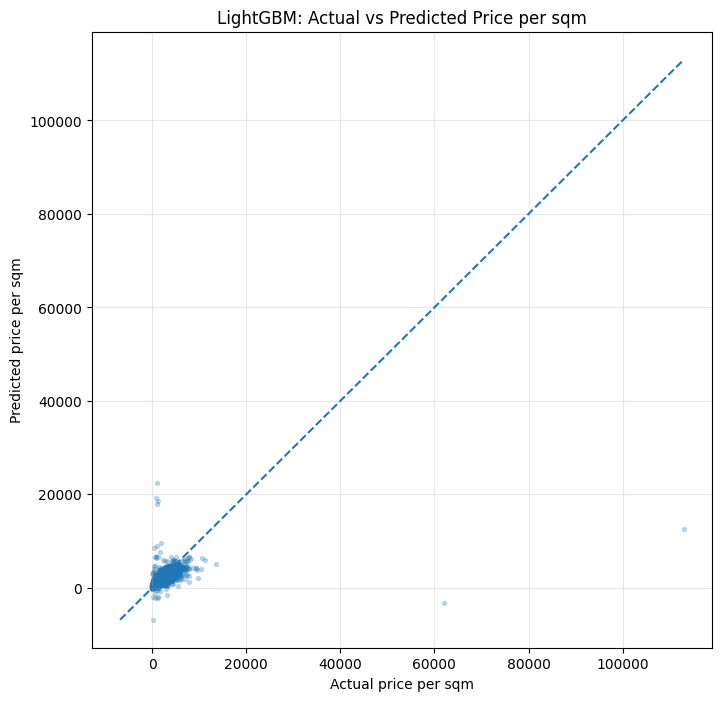

In [46]:
plt.figure(figsize=(8, 8))

plt.scatter(
    lgbm_error_df["actual_price_per_sqm"],
    lgbm_error_df["pred_price_per_sqm"],
    alpha=0.25,
    s=8
)

min_val = min(
    lgbm_error_df["actual_price_per_sqm"].min(),
    lgbm_error_df["pred_price_per_sqm"].min()
)

max_val = max(
    lgbm_error_df["actual_price_per_sqm"].max(),
    lgbm_error_df["pred_price_per_sqm"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("LightGBM: Actual vs Predicted Price per sqm")
plt.xlabel("Actual price per sqm")
plt.ylabel("Predicted price per sqm")
plt.grid(True, alpha=0.3)

plt.show()

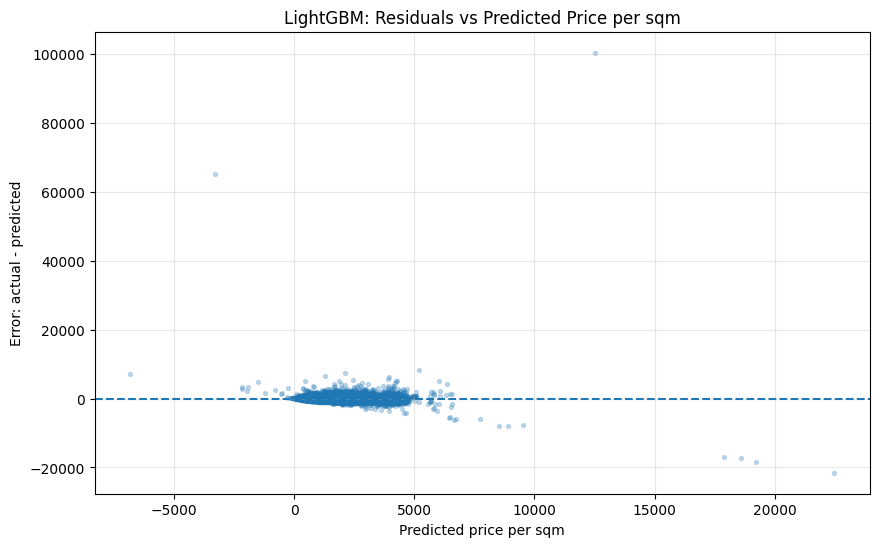

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    lgbm_error_df["pred_price_per_sqm"],
    lgbm_error_df["error"],
    alpha=0.25,
    s=8
)

plt.axhline(0, linestyle="--")

plt.title("LightGBM: Residuals vs Predicted Price per sqm")
plt.xlabel("Predicted price per sqm")
plt.ylabel("Error: actual - predicted")
plt.grid(True, alpha=0.3)

plt.show()

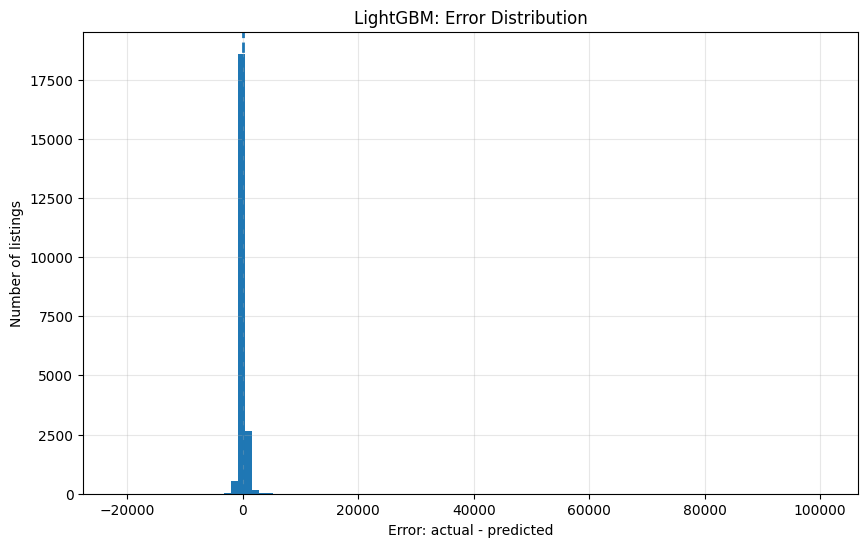

In [48]:
plt.figure(figsize=(10, 6))

plt.hist(lgbm_error_df["error"], bins=100)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("LightGBM: Error Distribution")
plt.xlabel("Error: actual - predicted")
plt.ylabel("Number of listings")
plt.grid(True, alpha=0.3)

plt.show()

In [49]:
param_grid = {
    "model__n_estimators": [500, 800],
    "model__learning_rate": [0.03, 0.05],
    "model__num_leaves": [31, 63],
    "model__max_depth": [-1, 10],
    "model__min_child_samples": [20, 40],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_lambda": [0.0, 1.0],
}

In [50]:
lgbm_grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            objective="regression",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

In [51]:
X_train_val_model = pd.concat([X_train_model, X_val_model], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

In [52]:
test_fold = np.concatenate([
    np.full(len(X_train_model), -1),
    np.zeros(len(X_val_model))
])

predefined_split = PredefinedSplit(test_fold)

In [59]:
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_grid_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=predefined_split,
    n_jobs=1,
    verbose=2,
    refit=True
)

grid_search_lgbm.fit(X_train_val_model, y_train_val)

Fitting 1 folds for each of 64 candidates, totalling 64 fits


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=-1, model__min_child_samples=20, model__n_estimators=500, model__num_leaves=31, model__reg_lambda=0.0, model__subsample=0.8; total time=  12.8s


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=-1, model__min_child_samples=20, model__n_estimators=500, model__num_leaves=31, model__reg_lambda=1.0, model__subsample=0.8; total time=  12.1s


...

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=10, model__min_child_samples=40, model__n_estimators=800, model__num_leaves=63, model__reg_lambda=0.0, model__subsample=0.8; total time=  16.1s


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=10, model__min_child_samples=40, model__n_estimators=800, model__num_leaves=63, model__reg_lambda=1.0, model__subsample=0.8; total time=  13.3s


,estimator,Pipeline(step...rbosity=-1))])
,param_grid,"{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.03, 0.05], 'model__max_depth': [-1, 10], 'model__min_child_samples': [20, 40], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,"PredefinedSpl...ape=(85948,)))"
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


In [60]:
# Check LightGBM GridSearchCV results


# Best params and best validation MAE from GridSearchCV
print("Best params:")
print(grid_search_lgbm.best_params_)

print("\nBest CV MAE:")
print(-grid_search_lgbm.best_score_)

# Full grid results
lgbm_grid_results_df = pd.DataFrame(grid_search_lgbm.cv_results_).copy()

# Convert negative MAE to positive MAE
lgbm_grid_results_df["MAE"] = -lgbm_grid_results_df["mean_test_score"]

# Select useful columns
result_cols = [
    "rank_test_score",
    "MAE",
    "mean_fit_time",
    "std_fit_time",
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_lambda",
]

lgbm_grid_summary_df = (
    lgbm_grid_results_df[result_cols]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(lgbm_grid_summary_df.head(20))

# Optional: compare best grid score to previous baseline LightGBM validation MAE
baseline_lgbm_mae = 317.002163

print("\nBaseline LightGBM MAE:", baseline_lgbm_mae)
print("Best grid MAE:", -grid_search_lgbm.best_score_)
print("Improvement:", baseline_lgbm_mae - (-grid_search_lgbm.best_score_))

Best params:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 20, 'model__n_estimators': 800, 'model__num_leaves': 63, 'model__reg_lambda': 0.0, 'model__subsample': 0.8}

Best CV MAE:
300.35450831385697


,rank_test_score,MAE,mean_fit_time,std_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
0,1,300.354508,22.469763,0.0,800,0.05,63,-1,20,0.8,0.8,0.0
1,2,300.815475,23.283103,0.0,800,0.05,63,-1,20,0.8,0.8,1.0
2,3,305.356529,16.130896,0.0,500,0.05,63,-1,20,0.8,0.8,0.0
3,4,305.685657,24.284495,0.0,800,0.03,63,-1,20,0.8,0.8,0.0
4,5,305.752183,18.385420,0.0,500,0.05,63,-1,20,0.8,0.8,1.0
5,6,306.066368,28.334528,0.0,800,0.03,63,-1,20,0.8,0.8,1.0
6,7,306.868303,21.556466,0.0,800,0.05,63,-1,40,0.8,0.8,1.0
7,8,306.973988,25.577086,0.0,800,0.05,63,-1,40,0.8,0.8,0.0
8,9,307.989315,27.852574,0.0,800,0.05,63,10,20,0.8,0.8,0.0
9,10,308.759658,22.126192,0.0,800,0.05,63,10,20,0.8,0.8,1.0



Baseline LightGBM MAE: 317.002163
Best grid MAE: 300.35450831385697
Improvement: 16.647654686143028


In [61]:
# Get best params from GridSearchCV
best_params = grid_search_lgbm.best_params_

# Clean param names: remove "model__"
best_params_clean = {
    key.replace("model__", ""): value
    for key, value in best_params.items()
}

# Refit best model on train only, evaluate on val
best_lgbm_val_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            **best_params_clean,
            objective="regression",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

best_lgbm_val_model.fit(X_train_model, y_train)

y_val_pred_best = best_lgbm_val_model.predict(X_val_model)

best_lgbm_metrics = {
    "MAE": mean_absolute_error(y_val, y_val_pred_best),
    "RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred_best)),
    "R2": r2_score(y_val, y_val_pred_best),
}

best_lgbm_metrics

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MAE': 300.35450831385697,
 'RMSE': np.float64(463.45925897916703),
 'R2': 0.7546966834650728}

In [62]:
# Analyze which LightGBM hyperparameter directions improved MAE
grid_df = pd.DataFrame(grid_search_lgbm.cv_results_).copy()
grid_df["MAE"] = -grid_df["mean_test_score"]

param_cols = [
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_lambda",
]

print("Best params:")
display(grid_search_lgbm.best_params_)

print("\nBest MAE:")
display(grid_df["MAE"].min())

# 1. Average MAE by each hyperparameter value
for col in param_cols:
    print(f"\nAverage MAE by {col}:")
    display(
        grid_df
        .groupby(col, dropna=False)
        .agg(
            mean_MAE=("MAE", "mean"),
            median_MAE=("MAE", "median"),
            best_MAE=("MAE", "min"),
            count=("MAE", "size"),
            mean_fit_time=("mean_fit_time", "mean"),
        )
        .sort_values("mean_MAE")
    )

# 2. Top 15 configurations
top_configs = (
    grid_df
    .sort_values("MAE")
    [
        ["MAE", "mean_fit_time"] + param_cols
    ]
    .reset_index(drop=True)
)

print("\nTop 15 configs:")
display(top_configs.head(15))

# 3. Compare best config vs baseline config, if baseline was in grid
baseline_params = {
    "param_model__n_estimators": 500,
    "param_model__learning_rate": 0.05,
    "param_model__num_leaves": 31,
    "param_model__max_depth": -1,
    "param_model__min_child_samples": 20,
    "param_model__subsample": 0.8,
    "param_model__colsample_bytree": 0.8,
    "param_model__reg_lambda": 0.0,
}

baseline_mask = pd.Series(True, index=grid_df.index)

for col, value in baseline_params.items():
    if col in grid_df.columns:
        baseline_mask &= grid_df[col].astype(str).eq(str(value))

baseline_grid_rows = grid_df[baseline_mask]

print("\nBaseline-like rows found in grid:")
display(
    baseline_grid_rows[["MAE", "mean_fit_time"] + param_cols]
    if len(baseline_grid_rows) > 0
    else "No exact baseline config found in this grid."
)

Best params:


{'model__colsample_bytree': 0.8,
 'model__learning_rate': 0.05,
 'model__max_depth': -1,
 'model__min_child_samples': 20,
 'model__n_estimators': 800,
 'model__num_leaves': 63,
 'model__reg_lambda': 0.0,
 'model__subsample': 0.8}


Best MAE:


np.float64(300.35450831385697)


Average MAE by param_model__n_estimators:


...

,mean_MAE,median_MAE,best_MAE,count,mean_fit_time
param_model__reg_lambda,,,,,
0.0,317.188672,316.835837,300.354508,32,15.979029
1.0,317.595536,317.531661,300.815475,32,16.244946



Top 15 configs:


,MAE,mean_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
0,300.354508,22.469763,800,0.05,63,-1,20,0.8,0.8,0.0
1,300.815475,23.283103,800,0.05,63,-1,20,0.8,0.8,1.0
2,305.356529,16.130896,500,0.05,63,-1,20,0.8,0.8,0.0
3,305.685657,24.284495,800,0.03,63,-1,20,0.8,0.8,0.0
4,305.752183,18.385420,500,0.05,63,-1,20,0.8,0.8,1.0
5,306.066368,28.334528,800,0.03,63,-1,20,0.8,0.8,1.0
6,306.868303,21.556466,800,0.05,63,-1,40,0.8,0.8,1.0
7,306.973988,25.577086,800,0.05,63,-1,40,0.8,0.8,0.0
8,307.989315,27.852574,800,0.05,63,10,20,0.8,0.8,0.0
9,308.759658,22.126192,800,0.05,63,10,20,0.8,0.8,1.0



Baseline-like rows found in grid:


,MAE,mean_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
32,317.002163,12.33533,500,0.05,31,-1,20,0.8,0.8,0.0
